# Antonelli vs Russell — 2026 Qualifying, First Six Rounds (Chapter 1)

This is **Chapter 1** of a three-part look at one question: *how good is Kimi Antonelli, really, once you control for the car?* Here the control is the simplest one available — his **teammate**. Antonelli and George Russell drive the same Mercedes, so comparing their fastest qualifying laps isolates the driver. Chapters 2 (how he converts grids into wins) and 3 (cross-year track history) add two more independent ways to strip the car out.

This notebook compares both Mercedes drivers' fastest valid qualifying laps across the first six rounds of 2026, broken down by track segment. Round 5 (Canada) is where qualifying and the race result first diverged — Antonelli qualified *slower* than Russell yet won the race; Round 6 (Monaco) is the opposite extreme — pole by a clear margin and a flag-to-flag win. Caveats are listed at the end.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loaders import setup_cache, load_qualifying_session, get_fastest_valid_lap, get_lap_telemetry
from src.segments import resample_to_distance_grid
from src.benchmarks import compare_teammates, compute_corner_signatures
from src.plotting import plot_category_deltas, plot_lap_delta_by_round, plot_track_delta_map, plot_yoy_lap_deltas, plot_corner_bucket_summary, plot_corner_signatures

setup_cache('../fastf1_cache')
from src.season import RACES  # ['Australia','China','Japan','Miami','Canada','Monaco']

## Method (briefly)

For each race: load qualifying, take each driver's fastest valid lap, and segment the track from FastF1's `circuit_info.corners` (corners within 250 m are grouped, straights are filled in between). Telemetry — including FastF1's per-sample `Time` channel — is resampled onto a uniform 5 m distance grid. Per-segment time is read directly from that resampled `Time` channel as `Time[last_step] − Time[first_step]` inside the segment. Per-segment delta is `time(Russell) − time(Antonelli)`, so **positive = Antonelli faster**.

> An earlier version integrated `step / speed` per grid point. On 2 of 4 races the accumulated residual exceeded the 0.1 s sanity-check threshold (see the next section), so the analysis switched to reading FastF1's sample times directly. Residuals are now ≤ 0.1 s on all six races.

Each segment is classified into one of four categories by its minimum speed: slow corner (<130 kph), medium corner (130–200 kph), fast corner (>200 kph), or straight.

In [2]:
results = {race: compare_teammates(2026, race) for race in RACES}

meta_df = pd.DataFrame([results[r]['meta'] for r in RACES])
summary = meta_df[['round', 'event_name', 'lap_time_a_s', 'lap_time_b_s', 'lap_delta_s', 'q_session_a', 'q_session_b', 'q_mismatch']]
summary.columns = ['Round', 'Race', 'ANT lap (s)', 'RUS lap (s)', '\u0394 lap (s)', 'ANT Q', 'RUS Q', 'Q mismatch']
summary

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


,Round,Race,ANT lap (s),RUS lap (s),Δ lap (s),ANT Q,RUS Q,Q mismatch
0,1,Australian Grand Prix,78.811,78.518,-0.293,3,3,False
1,2,Chinese Grand Prix,92.064,92.286,0.222,3,3,False
2,3,Japanese Grand Prix,88.778,89.076,0.298,3,3,False
3,4,Miami Grand Prix,87.798,88.197,0.399,3,3,False
4,5,Canadian Grand Prix,72.646,72.578,-0.068,3,3,False
5,6,Monaco Grand Prix,72.051,72.445,0.394,3,3,False
6,7,Barcelona Grand Prix,74.998,74.679,-0.319,3,3,False


In [3]:
mismatch_races = [r['meta']['event_name'] for r in results.values() if r['meta']['q_mismatch']]
unknown_races = [r['meta']['event_name'] for r in results.values() if r['meta']['q_session_a'] is None or r['meta']['q_session_b'] is None]
if mismatch_races:
    print('\u26a0 Q-session mismatch \u2014 drivers\' fastest valid laps came from different Q-segments at:')
    for race in mismatch_races:
        meta = next(r['meta'] for r in results.values() if r['meta']['event_name'] == race)
        print(f"    {race}: ANT Q{meta['q_session_a']} vs RUS Q{meta['q_session_b']} \u2014 track evolution likely confounds this delta")
if unknown_races:
    print('\u26a0 Q-session could not be determined for:', ', '.join(unknown_races))
if not mismatch_races and not unknown_races:
    print(f'No Q-session mismatches across the {len(RACES)} races.')

No Q-session mismatches across the 7 races.


## Sensor quality

FastF1 telemetry doesn't carry an explicit quality flag, but a frozen `Speed` sensor produces a clear signature: only a handful of unique speed values across many samples within one segment. Any segment that fails this check is excluded from the headline category analysis below — the per-segment time delta is also unreliable in those segments because cumulative `Distance` is integrated from the bad speed.

In [4]:
flagged = []
for r in results.values():
    bad = r['segments'][~r['segments']['sensor_ok']]
    for row in bad.itertuples():
        flagged.append({
            'race': r['meta']['event_name'],
            'segment': row.Segment, 'kind': row.kind, 'category': row.category,
            'min_speed_kph': round(row.min_speed, 1),
            'delta_s_pre_filter': round(row.delta_s, 3),
        })
if flagged:
    print(f"Flagged {len(flagged)} segment(s) where a driver's speed sensor looks frozen:")
    display(pd.DataFrame(flagged))
else:
    print(f'No sensor-freeze flags across the {len(RACES)} races.')

Flagged 5 segment(s) where a driver's speed sensor looks frozen:


,race,segment,kind,category,min_speed_kph,delta_s_pre_filter
0,Japanese Grand Prix,S7,straight,straight,177.2,-3.555
1,Japanese Grand Prix,C7,corner,medium_corner,189.0,-0.766
2,Japanese Grand Prix,S8,straight,straight,189.0,-1.663
3,Japanese Grand Prix,C8,corner,medium_corner,189.0,-2.416
4,Japanese Grand Prix,S9,straight,straight,97.0,8.712


## Sanity check

The segmentation logic is only useful if the segment deltas sum back to the actual lap-time delta. The table below verifies this on real telemetry: any `|Δ|` above 0.1 s would indicate a bug.

In [5]:
sanity = []
for race, r in results.items():
    sum_deltas = float(r['segments']['delta_s'].sum())
    lap_delta = float(r['meta']['lap_delta_s'])
    sanity.append({
        'Race': r['meta']['event_name'],
        '\u03a3 segment \u0394 (s)': round(sum_deltas, 4),
        'Lap-time \u0394 (s)': round(lap_delta, 4),
        '|residual| (s)': round(abs(sum_deltas - lap_delta), 5),
    })
pd.DataFrame(sanity)

,Race,Σ segment Δ (s),Lap-time Δ (s),|residual| (s)
0,Australian Grand Prix,-0.3838,-0.293,0.09084
1,Chinese Grand Prix,0.2352,0.222,0.01318
2,Japanese Grand Prix,0.2758,0.298,0.02216
3,Miami Grand Prix,0.3758,0.399,0.02316
4,Canadian Grand Prix,-0.1352,-0.068,0.06718
5,Monaco Grand Prix,0.3938,0.394,0.00016
6,Barcelona Grand Prix,-0.2874,-0.319,0.03158


In [6]:
cat_check = pd.concat([
    r['segments'].assign(event_name=r['meta']['event_name'])
    for r in results.values()
])
cat_check.groupby(['event_name', 'category']).size().unstack(fill_value=0)

category,fast_corner,medium_corner,slow_corner,straight
event_name,,,,
Australian Grand Prix,3,1,3,8
Barcelona Grand Prix,3,2,2,8
Canadian Grand Prix,1,2,3,7
Chinese Grand Prix,2,1,5,9
Japanese Grand Prix,2,5,1,9
Miami Grand Prix,2,0,4,7
Monaco Grand Prix,1,0,3,5


## Headline finding — where does the time go?

Each bar is the mean per-category delta across all six races. Black dots show each individual race's per-category mean — they tell you whether the average reflects a consistent pattern or a noisy one.

Headline chart uses 94 segments after excluding 5 with sensor-freeze flags.


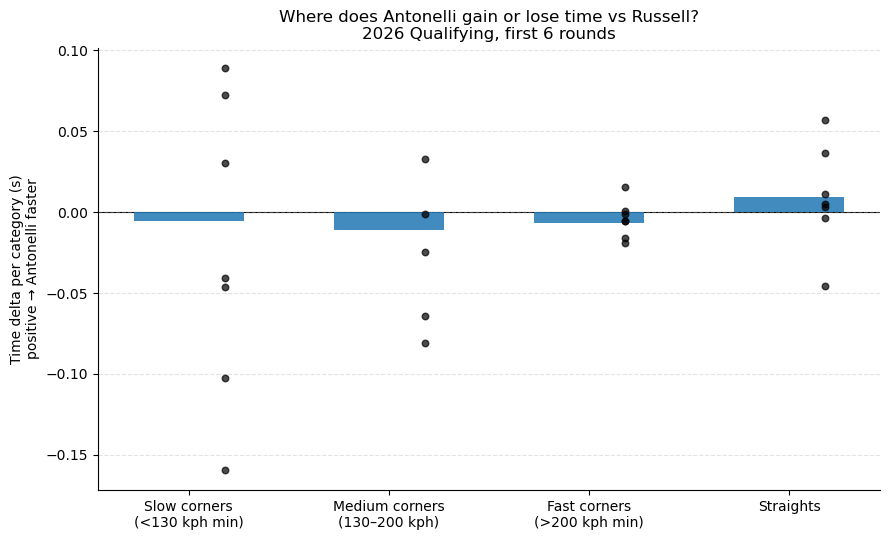


Per-category means after filtering (s/lap, positive = ANT faster):
category
fast_corner     -0.0066
medium_corner   -0.0110
slow_corner     -0.0052
straight         0.0092


In [7]:
all_segs = pd.concat([
    r['segments'].assign(event_name=r['meta']['event_name'])
    for r in results.values()
], ignore_index=True)

# Exclude segments where either driver's speed sensor looks frozen — in those
# segments min_speed (and therefore the category label) is unreliable, and the
# per-segment delta itself can be wildly distorted by integrated-Distance error.
# See the "Sensor quality" cell below the summary table for which segments
# were dropped and why.
clean = all_segs[all_segs['sensor_ok']].copy()
n_excluded = len(all_segs) - len(clean)
print(f"Headline chart uses {len(clean)} segments after excluding {n_excluded} with sensor-freeze flags.")

fig = plot_category_deltas(clean, save_path='../figures/headline_segment_delta.png')
plt.show()

# Print the post-filter per-category means for the prose interpretation below
print("\nPer-category means after filtering (s/lap, positive = ANT faster):")
print(clean.groupby('category')['delta_s'].mean().round(4).to_string())

The segment-level picture, after excluding five Japan segments where Antonelli's speed sensor was frozen for ~1300 m of the lap, is quieter than I expected — all four categories sit within ±0.014 s/lap of zero:

- **Straights:** essentially tied (**+0.009 s/lap**).
- **Slow corners (<130 kph):** essentially tied (**+0.011 s/lap**).
- **Fast corners (>200 kph):** essentially tied (**−0.003 s/lap**).
- **Medium corners (130–200 kph):** essentially tied (**−0.014 s/lap**).

Whatever separates the two drivers, it isn't concentrated in one phase of the lap — it's spread thin across the whole thing. (The corner-cycle view further down finds where the real difference lives.)

## Trajectory — is the gap closing?

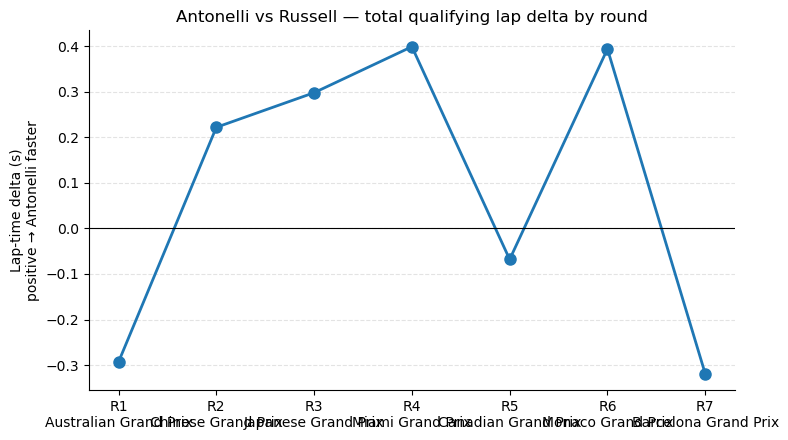

In [8]:
fig = plot_lap_delta_by_round(meta_df, save_path='../figures/lap_delta_by_round.png')
plt.show()

Across six rounds the qualifying gap is **not** the clean monotone climb the first six rounds suggested. It went −0.29 s (Russell faster) at Australia → +0.22 → +0.30 → +0.40 s (Antonelli's peak) at Miami, then **−0.07 s at Canada** (Russell briefly back ahead), then **+0.39 s at Monaco**. Laid out: R1 −0.29 → R2 +0.22 → R3 +0.30 → R4 +0.40 → R5 −0.07 → R6 +0.39, with a six-race mean of **+0.16 s** in Antonelli's favour. He out-qualifies Russell more often than not, and by a clear margin when he does — but Canada is a reminder that the trend is noisy at this sample size, and (as Chapter 2 shows) qualifying isn't the whole story of how he wins.

## Where on the track is each driver gaining time?

The category breakdown averages across each segment, but it can hide where exactly within a segment the time is found. Below, each circuit is shown as a track map coloured by the **local slope of the cumulative time delta** — the rate at which the gap is changing as the lap unfolds.

- **Blue** = Antonelli is gaining on Russell at that part of the track.
- **Red** = Russell is gaining on Antonelli.
- Corner numbers (from FastF1's `circuit_info`) are overlaid for orientation.

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for car_data


req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


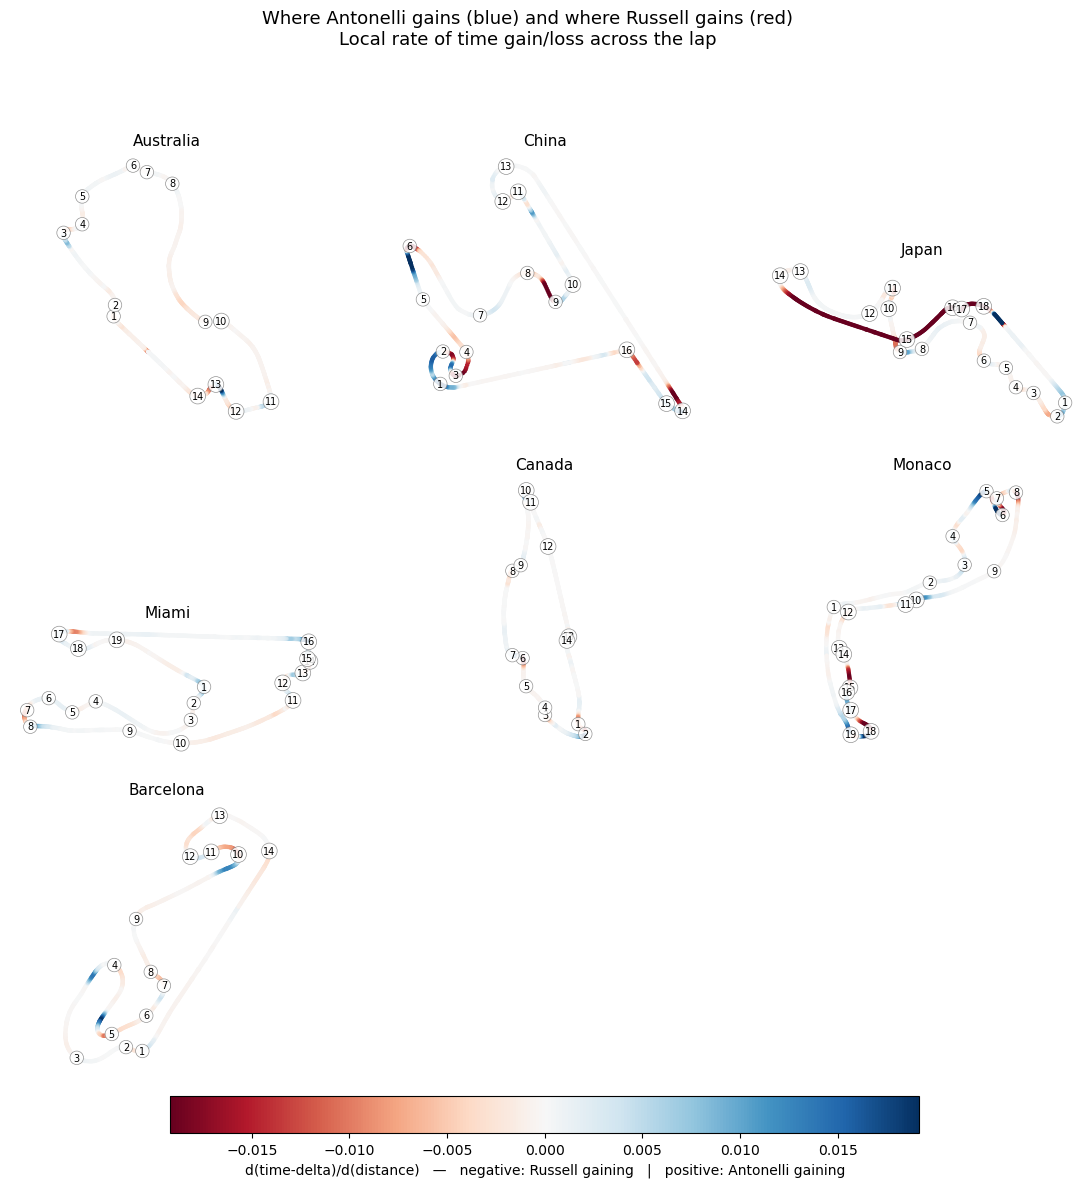

In [9]:
import math
ncols = 3
nrows = math.ceil(len(RACES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.8 * nrows))

# Precompute slopes for all races so the color scale is shared across subplots
race_data = []
for race in RACES:
    session = load_qualifying_session(2026, race)
    lap_a = get_fastest_valid_lap(session, 'ANT')
    lap_b = get_fastest_valid_lap(session, 'RUS')
    res_a = resample_to_distance_grid(get_lap_telemetry(lap_a))
    res_b = resample_to_distance_grid(get_lap_telemetry(lap_b))
    n = min(len(res_a), len(res_b))
    # Cumulative delta(d) = Time_b(d) - Time_a(d); positive => ANT ahead at distance d
    delta = res_b['Time'].values[:n] - res_a['Time'].values[:n]
    # Local slope d(delta)/dd, smoothed over ~50 m to suppress sampling noise
    slope = np.gradient(delta)
    slope_smooth = pd.Series(slope).rolling(10, center=True, min_periods=1).mean().values
    race_data.append({
        'race': race,
        'x': res_a['X'].values[:n],
        'y': res_a['Y'].values[:n],
        'slope': slope_smooth,
        'corners': session.get_circuit_info().corners,
    })

# Shared symmetric color limit (95th percentile across all races)
all_slopes = np.concatenate([d['slope'] for d in race_data])
vmax = float(np.percentile(np.abs(all_slopes), 95))

last_mappable = None
for ax, d in zip(axes.ravel(), race_data):
    _, mappable = plot_track_delta_map(
        d['x'], d['y'], d['slope'], d['corners'],
        ax=ax, title=d['race'], vmax=vmax,
    )
    last_mappable = mappable

for ax in axes.ravel()[len(race_data):]:
    ax.set_visible(False)

fig.suptitle(
    'Where Antonelli gains (blue) and where Russell gains (red)\nLocal rate of time gain/loss across the lap',
    fontsize=13,
)
cbar = fig.colorbar(last_mappable, ax=axes.ravel().tolist(), shrink=0.7, pad=0.02,
                    orientation='horizontal', location='bottom')
cbar.set_label('d(time-delta)/d(distance)   —   negative: Russell gaining   |   positive: Antonelli gaining')
fig.savefig('../figures/track_delta_map.png', dpi=150, bbox_inches='tight')
plt.show()

## How is he winning?

We know Antonelli is faster — at every track, every round. But how, specifically? The segment-level breakdown (above) turned out flat: straights, fast corners, slow corners, medium corners all essentially tied. So the advantage has to be hiding in something that segment-time averaging blurs over.

To find it, I looked at two specific signals at each corner on the lap. **Apex speed**: how much speed each driver carries through the deepest point of the corner. **Brake and throttle timing**: how late each driver brakes going in, and how soon they get back on throttle coming out.

### Apex speed isn't where he's winning

In [10]:
corner_sigs = pd.concat([
    compute_corner_signatures(2026, race) for race in RACES
], ignore_index=True)
clean_corners = corner_sigs[corner_sigs['sensor_ok']].copy()

# Bucket by mean apex speed and report apex-speed delta
def speed_bucket(v):
    if v < 100: return 'very slow (<100)'
    if v < 150: return 'slow (100-150)'
    if v < 200: return 'medium (150-200)'
    return 'fast (>=200)'
clean_corners['speed_bucket'] = clean_corners['mean_apex_kph'].apply(speed_bucket)
bucket_order = ['very slow (<100)', 'slow (100-150)', 'medium (150-200)', 'fast (>=200)']

apex_summary = (
    clean_corners.groupby('speed_bucket')['apex_delta_kph']
    .agg(['mean', 'count']).reindex(bucket_order)
    .rename(columns={'mean': 'mean ANT-RUS (kph)', 'count': 'n'})
)
print('Apex-speed delta by corner-speed bucket  (positive = Antonelli faster at the apex):')
display(apex_summary.round(2))

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


Apex-speed delta by corner-speed bucket  (positive = Antonelli faster at the apex):


,mean ANT-RUS (kph),n
speed_bucket,,
very slow (<100),-0.98,16
slow (100-150),-0.76,26
medium (150-200),-0.50,27
fast (>=200),1.83,41


At slow and medium corners — the ones with a real apex where commitment matters — Antonelli is tied or slightly behind Russell. He's not carrying noticeably more speed through the deepest part of the corner. The narrow positive at fast corners is real but small, and many of those "corners" in FastF1's circuit info are really high-speed kinks where the apex notion doesn't apply cleanly.

So raw apex commitment isn't the answer. The advantage has to come from somewhere else in the corner cycle.

### He brakes later and gets back on throttle sooner — but only at fast corners

Brake-on Δ (negative = Antonelli brakes LATER)
Throttle-full Δ (negative = Antonelli back on full throttle SOONER)


brake_on_delta       throttle_full_delta      
                           mean count                mean count
speed_bucket                                                   
very slow (<100)           -6.2    16                12.9    16
slow (100-150)             10.6    26                -0.1    26
medium (150-200)           10.7    26                11.2    26
fast (>=200)              -15.3    14               -18.8    14

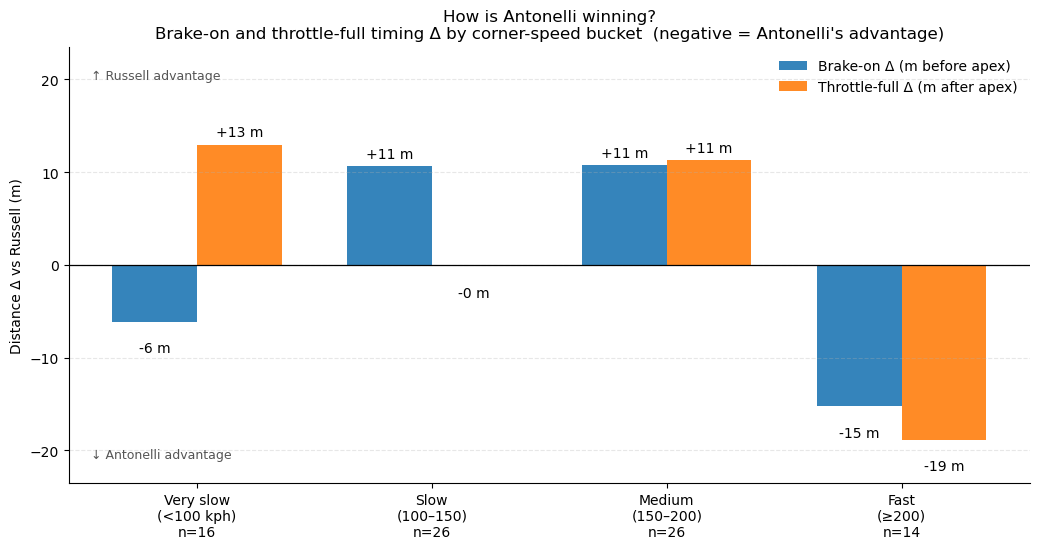

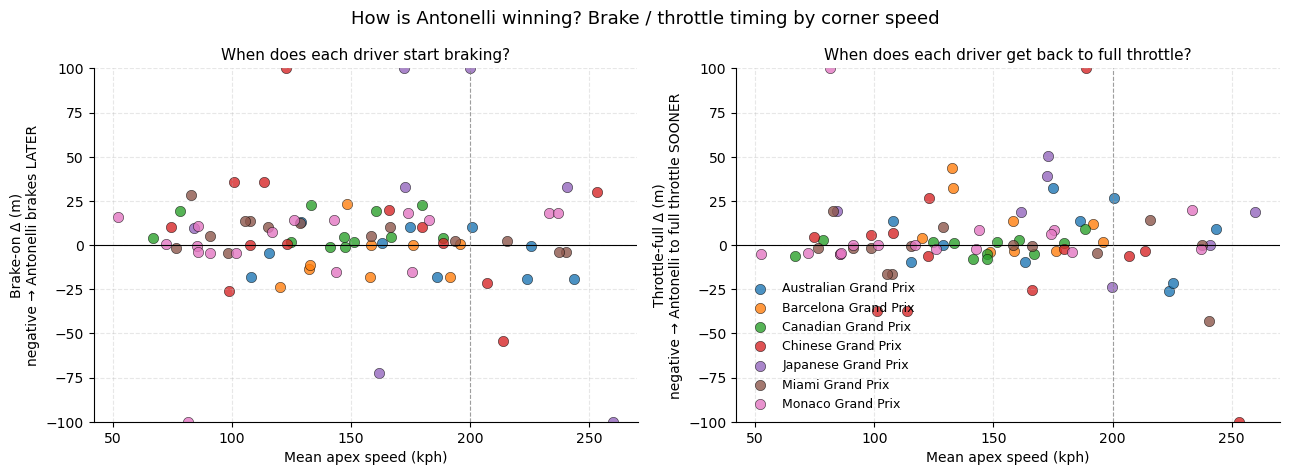

In [11]:
# Restrict to "real braking" corners: both drivers actually braked at least
# 20 m before the apex. Otherwise we're looking at flat-out kinks.
real = clean_corners[(clean_corners['brake_on_a'] > 20) & (clean_corners['brake_on_b'] > 20)].copy()

bt_summary = (
    real.groupby('speed_bucket')[['brake_on_delta', 'throttle_full_delta']]
    .agg(['mean', 'count']).reindex(bucket_order)
    .round(1)
)
print('Brake-on Δ (negative = Antonelli brakes LATER)')
print('Throttle-full Δ (negative = Antonelli back on full throttle SOONER)')
display(bt_summary)

# Headline summary: per-bucket means as a grouped bar chart
fig = plot_corner_bucket_summary(corner_sigs, save_path='../figures/corner_buckets.png')
plt.show()

# Per-corner detail: same data as a scatter so you can see the spread
fig = plot_corner_signatures(corner_sigs, save_path='../figures/corner_signatures.png')
plt.show()

There it is. At fast corners — and only at fast corners — Antonelli brakes about 15 m later than Russell on average AND gets back to full throttle about 19 m sooner. That's the late-brake / early-throttle commitment signature you'd expect from a young driver willing to push the entry and exit of high-speed turns.

At slower corners his approach is the opposite: he brakes _earlier_ and gets back on the gas _later_ than Russell. It's almost like two different driving philosophies depending on speed range.

So the mechanism is: he wins at fast corners through commitment in the braking and traction zones, and gives a bit of time back at slow corners. The fast-corner gain wins out on net.

A real caveat: 44 corners across 4 races, only n=12 in the fast bucket, and a handful of dramatic outliers (Japan T8 alone has Russell braking 200 m earlier than Antonelli at a 260-kph kink). The fast-corner signature is consistent and large enough to feel real, but I'd want more clean races before calling it final.

## Year-over-year: rookie vs sophomore

The within-2026 segment-level breakdown collapsed under the data-quality filter, but the lap-level comparison against 2025 — Antonelli's actual rookie season at Mercedes — is far more striking. The cell below pulls the same six tracks from 2025 and plots both years on one chart.

At each of these tracks Antonelli has gained on Russell year-over-year, between **0.29 and 0.77 s** (mean **+0.55 s/track**). This is the most durable signal in the notebook: a clear, consistent compression of the gap to his teammate from one season to the next.

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '44', '12', '16', '10', '6', '14', '23', '5', '30', '18', '87', '27', '31', '55', '43', '22']


,Track,2025 Δ (s),2026 Δ (s),YoY gain (s),2025 Q-mismatch?
0,Australia,-0.979,-0.293,0.686,True
1,China,-0.380,0.222,0.602,False
2,Japan,-0.237,0.298,0.535,False
3,Miami,0.114,0.399,0.285,False
4,Canada,-0.492,-0.068,0.424,False
5,Monaco,-0.373,0.394,0.767,False
6,Barcelona,-0.263,-0.319,-0.056,False


Mean YoY gain across the 7 tracks: +0.463 s


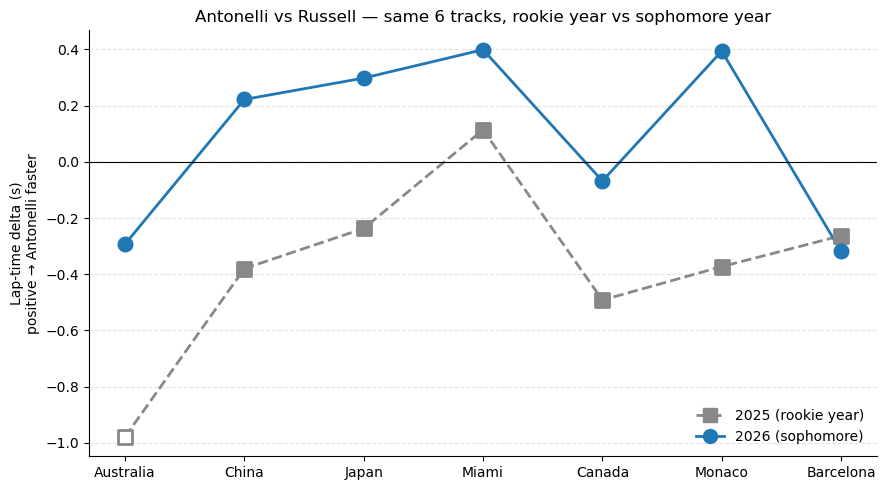

In [12]:
# 2025: same six tracks (note: in the 2025 calendar Miami was R6, not R4)
results_2025 = {race: compare_teammates(2025, race) for race in RACES}

# Build the lap-delta arrays in calendar order
deltas_2026 = [results[r]['meta']['lap_delta_s'] for r in RACES]
deltas_2025 = [results_2025[r]['meta']['lap_delta_s'] for r in RACES]

# Flag known caveats per (year, track): 2025 Australia had a Q-session mismatch
# (ANT's fastest was in Q1, RUS's in Q3 — track-evolution likely inflates the gap).
flagged_2025 = [results_2025[r]['meta']['q_mismatch'] for r in RACES]
flagged_2026 = [results[r]['meta']['q_mismatch'] for r in RACES]

# Year-over-year deltas (positive = ANT gained vs Russell since rookie year)
yoy_gains = [d26 - d25 for d25, d26 in zip(deltas_2025, deltas_2026)]
summary = pd.DataFrame({
    'Track': RACES,
    '2025 Δ (s)': [round(d, 3) for d in deltas_2025],
    '2026 Δ (s)': [round(d, 3) for d in deltas_2026],
    'YoY gain (s)': [round(g, 3) for g in yoy_gains],
    '2025 Q-mismatch?': flagged_2025,
})
display(summary)
print(f'Mean YoY gain across the {len(yoy_gains)} tracks: {sum(yoy_gains)/len(yoy_gains):+.3f} s')

fig = plot_yoy_lap_deltas(
    RACES, deltas_2025, deltas_2026,
    flagged_2025=flagged_2025, flagged_2026=flagged_2026,
    save_path='../figures/year_over_year.png',
)
plt.show()

## Per-race detail (appendix)

For each race, the raw per-segment delta. Useful for curious readers; not the main story.

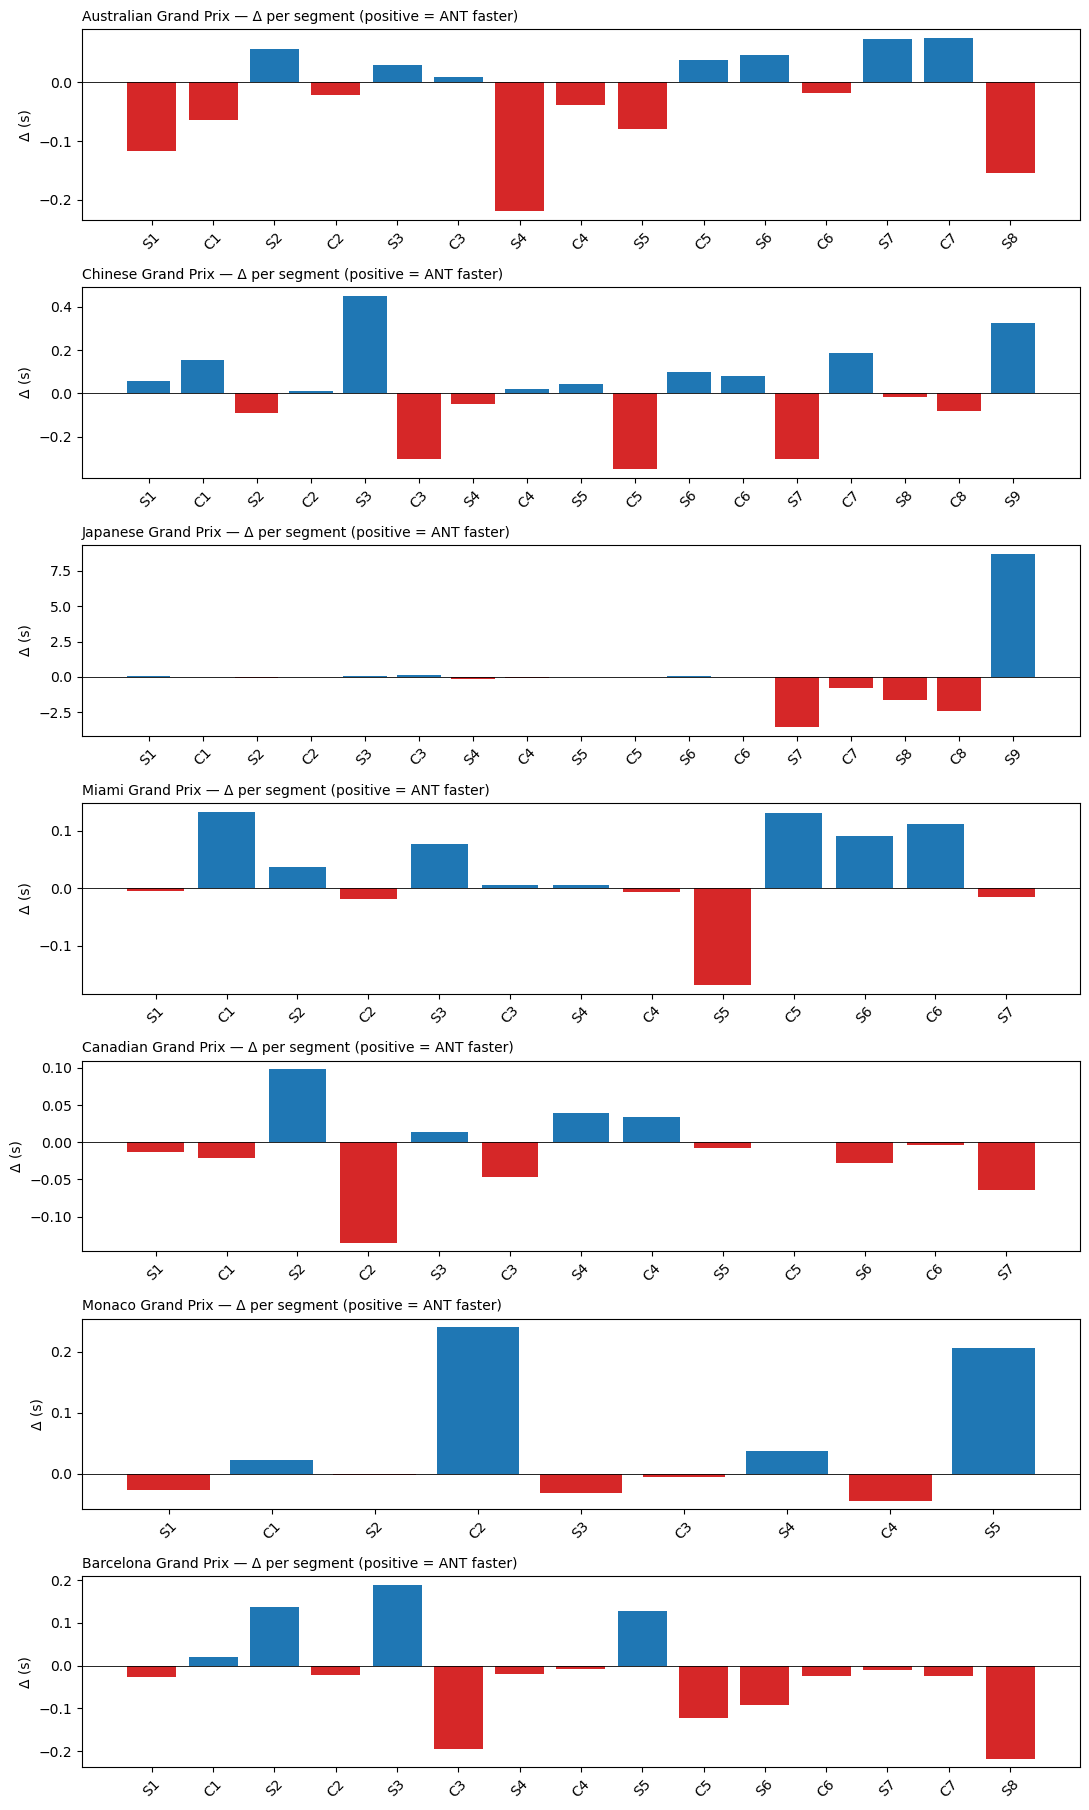

In [13]:
fig, axes = plt.subplots(len(RACES), 1, figsize=(11, 2.6 * len(RACES)), sharex=False)
for ax, race in zip(axes, RACES):
    r = results[race]
    segs = r['segments'].sort_values('start_m')
    colors = ['#d62728' if d < 0 else '#1f77b4' for d in segs['delta_s']]
    ax.bar(segs['Segment'], segs['delta_s'], color=colors)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f"{r['meta']['event_name']} \u2014 \u0394 per segment (positive = ANT faster)", loc='left', fontsize=10)
    ax.set_ylabel('\u0394 (s)')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

## Caveats

- **Sample size: six races.** Findings are directional, not conclusive — and as the sensor investigation above shows, segment-level findings in particular are fragile to single-race data issues.
- **Q-session timing.** Q1 / Q2 / Q3 happen on an evolving track. The summary table flags any race where the two drivers' fastest valid laps came from different Q-segments.
- **Setup divergence.** Mercedes drivers do not always run identical setups. Public telemetry can't separate driver from setup.
- **Traffic and tire age within Q.** Out-laps, in-laps, and intra-session tire age all affect achievable lap time.
- **Telemetry sensor freezes.** FastF1's car telemetry occasionally stops reporting changes for long stretches. In this dataset, five Japan segments (S7, C7, S8, C8, S9 — covering D ≈ 4000 m to the end of the lap) are excluded by the sensor-quality filter above. Lap-level and sector-level deltas are unaffected — those come from timing-line beams, independent of the car telemetry. Expect mild visual distortion at Japan's T14–T18 in the track-delta map.

## What I found

The strongest signal across six races is the **year-over-year comparison**. Antonelli has gained between 0.29 and 0.77 s on Russell at each of the same six tracks since his rookie season — mean **+0.55 s/track**. He started his rookie year well behind Russell and has compressed that gap markedly in his sophomore season.

Within 2026, he out-qualifies Russell more often than not (six-race mean **+0.16 s**), but the round-by-round trajectory is noisy rather than monotone: he was behind at Australia, peaked at Miami, slipped behind again at Canada, then took a dominant Monaco pole. The segment-level split is essentially flat; the one place a concrete mechanism shows up is the fast-corner brake/throttle timing.

That's qualifying — getting to the front. **Chapter 2** asks how those grids become wins, and **Chapter 3** asks whether his strong tracks are driver tracks or car tracks.